# 003 - Dataset EDA and Source-Choice Audit

This notebook inspects the dataset produced by `02_build_anime_dataset.py`.

It does not mutate the dataset. Its job is to identify:

- which final fields are still empty or zero-like
- which source fields disagree
- which source usually wins the final selected value
- examples that need manual review or later rule changes

This step replaces the older cleanup-first notebook. The new pipeline keeps source payloads raw, builds a transparent catalog, and then uses EDA to decide whether a rule should change.


In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

SCRIPT = BASE_DIR / "src" / "03_run_catalog_eda.py"
SUMMARY = BASE_DIR / "data" / "build" / "dataset_eda_summary.json"
EMPTY_AUDIT = BASE_DIR / "data" / "build" / "audits" / "dataset_empty_field_audit.csv"
CHOICE_AUDIT = BASE_DIR / "data" / "build" / "audits" / "dataset_source_choice_audit.csv"
DISCREPANCY_EXAMPLES = BASE_DIR / "data" / "build" / "audits" / "dataset_source_discrepancy_examples.csv"
MISSINGNESS_PLOT = BASE_DIR / "artifacts" / "plots" / "eda" / "dataset_missingness_audit.png"
CHOICE_PLOT = BASE_DIR / "artifacts" / "plots" / "eda" / "dataset_choice_disagreements.png"

print("Project:", BASE_DIR)
print("EDA script:", SCRIPT)



def run_streaming(command, cwd=None):
    """Run a script and print stdout/stderr line-by-line while it is still running."""
    cwd = cwd or globals().get("BASE_DIR") or globals().get("ROOT") or Path.cwd()
    command = [str(part) for part in command]
    print("Running:", " ".join(command), flush=True)
    process = subprocess.Popen(
        command,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
    return_code = process.wait()
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command)
    return return_code


Project: C:\Users\CHAMPUX\Downloads\UPC TRABAJOS 2026\BIG DATA\proyect
EDA script: C:\Users\CHAMPUX\Downloads\UPC TRABAJOS 2026\BIG DATA\proyect\src\03_run_catalog_eda.py


## Run the Audit

Run this after `002`. The script writes CSV tables and plots, then prints a compact JSON summary.


In [2]:
RUN_EDA = True
if RUN_EDA:
    run_streaming([sys.executable, str(SCRIPT)])


Running: c:\Users\CHAMPUX\AppData\Local\Programs\Python\Python313\python.exe C:\Users\CHAMPUX\Downloads\UPC TRABAJOS 2026\BIG DATA\proyect\src\03_run_catalog_eda.py
{
  "updated_at": "2026-07-11T03:23:03",
  "rows": 15492,
  "columns": 35,
  "empty_audit_csv": "C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_empty_field_audit.csv",
  "choice_audit_csv": "C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_source_choice_audit.csv",
  "discrepancy_examples_csv": "C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_source_discrepancy_examples.csv",
  "recap_audit_csv": "C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_recap_flag_audit.csv",
  "missingness_plot": "C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\artifacts\\plots\\eda\\dataset_missingness_audit.png",
  "choice_plot":

## Empty Field Audit

This table ranks important fields by missingness. Empty genres/tags mean AniList had no usable label source; empty characters or voice actors mean the character endpoint did not provide useful Japanese VA data.


In [3]:
empty_audit = pd.read_csv(EMPTY_AUDIT)
display(empty_audit)


,field,missing_count,missing_pct,zero_count,non_empty_count,example_missing_titles
0,relations,5277,34.063,0,10215,32281:Kimi no Na wa. | 22535:Kiseijuu: Sei no ...
1,demographics,3541,22.857,0,11951,32281:Kimi no Na wa. | 4224:Toradora! | 28121:...
2,recommendations,3480,22.463,0,12012,27821:Fate/stay night: Unlimited Blade Works P...
3,voice_actors,3226,20.824,0,12266,5365:Tsumiki no Ie | 601:Nekojiru-sou | 731:In...
4,anidb_id,1965,12.684,0,13527,27601:Chuunibyou demo Koi ga Shitai! Ren: The ...
5,characters,1699,10.967,0,13793,35658:Kuroko no Basket: Last Game NG-shuu | 40...
6,anilist_id,894,5.771,0,14598,27821:Fate/stay night: Unlimited Blade Works P...
7,studios,565,3.647,0,14927,13677:Ao no Exorcist Movie Special | 37278:Swo...
8,source,354,2.285,0,15138,18053:Koi to Senkyo to Chocolate: Ikenai Hazuk...
9,tags,121,0.781,0,15371,38653:Dragon Ball Super: Broly - Skytree Super...


## Source Choice Audit

For comparable fields, the final value is chosen by majority agreement when possible. If no two sources agree, the fallback order is `MAL > AniList > AniDB`. The audit uses normalized comparison keys, so formatting-only differences such as `TV Special` vs `Special`, `VIDEO_GAME` vs `Game`, `Kids` vs `Kodomo`, studio casing, studio order, punctuation, and a leading `Studio` prefix are not counted as real disagreements.

This table shows where sources disagree and which source tends to provide the selected value.


In [4]:
choice_audit = pd.read_csv(CHOICE_AUDIT)
display(choice_audit)


,field,source_columns,rows,rows_with_any_source,selected_missing_rows,consensus_rows,no_consensus_rows,source_disagreement_rows,selected_source_counts,unique_normalized_values


## Disagreement Examples

These are concrete rows where source values differ. Use this table to decide whether the consensus rule should be adjusted for a specific field.


In [5]:
if DISCREPANCY_EXAMPLES.exists():
    discrepancy_examples = pd.read_csv(DISCREPANCY_EXAMPLES)
    display(discrepancy_examples.head(100))
else:
    print("No discrepancy examples found. Run 002 first.")


,field,mal_id,title,popularity,selected_value,unique_raw_values,unique_normalized_values,mal_value,anilist_value,anidb_value,derived_value
0,demographics,44511,Chainsaw Man,47,Shounen,Shounen|Shounen|Seinen,seinen|shounen|shounen,Shounen,Shounen,Shounen|Seinen,NaN
1,demographics,8074,Highschool of the Dead,82,Shounen,Shounen|Shounen|Seinen,seinen|shounen|shounen,Shounen,Shounen,Shounen|Seinen,NaN
2,demographics,31478,Bungou Stray Dogs,91,Seinen,Seinen|Shounen|Seinen,seinen|seinen|shounen,Seinen,Seinen,Shounen|Seinen,NaN
3,demographics,6746,Durarara!!,99,Seinen,Seinen|Shoujo|Seinen,seinen|seinen|shoujo,NaN,Seinen,Shoujo|Seinen,NaN
4,demographics,14741,Chuunibyou demo Koi ga Shitai!,102,Shounen,Seinen|Shounen,seinen|shounen,NaN,Shounen,Seinen,NaN
...,...,...,...,...,...,...,...,...,...,...,...
95,demographics,1120,Pokemon Movie 05: Mizu no Miyako no Mamorigami...,2003,Kodomo,Kodomo|Shounen,kodomo|shounen,Kodomo,Kodomo,Shounen,NaN
96,demographics,25649,Junjou Romantica 3,2017,Shoujo,Josei|Shoujo,josei|shoujo,NaN,Shoujo,Josei,NaN
97,demographics,36317,Gaikotsu Shotenin Honda-san,2025,Shoujo,Shoujo|Shounen,shoujo|shounen,NaN,Shoujo,Shounen,NaN
98,demographics,1526,Pokemon Movie 08: Mew to Hadou no Yuusha Lucario,2033,Kodomo,Kodomo|Shounen,kodomo|shounen,Kodomo,Kodomo,Shounen,NaN


## Recap Flag Audit

Recap-like rows are not automatically bad. The build deletes low-engagement recap filler, but keeps rows with enough audience traction or long/complete compilation runtime and flags them here for review.


In [6]:
RECAP_AUDIT = BASE_DIR / "data" / "build" / "audits" / "dataset_recap_flag_audit.csv"
if RECAP_AUDIT.exists():
    recap_audit = pd.read_csv(RECAP_AUDIT)
    display(recap_audit.head(100))
else:
    print("No recap audit file found.")


EmptyDataError: No columns to parse from file

## Visual Summary

The plots make it easier to see which fields need attention first. The goal is not zero missingness everywhere; some fields are naturally sparse. The point is to identify whether missingness blocks representation-12 modeling.


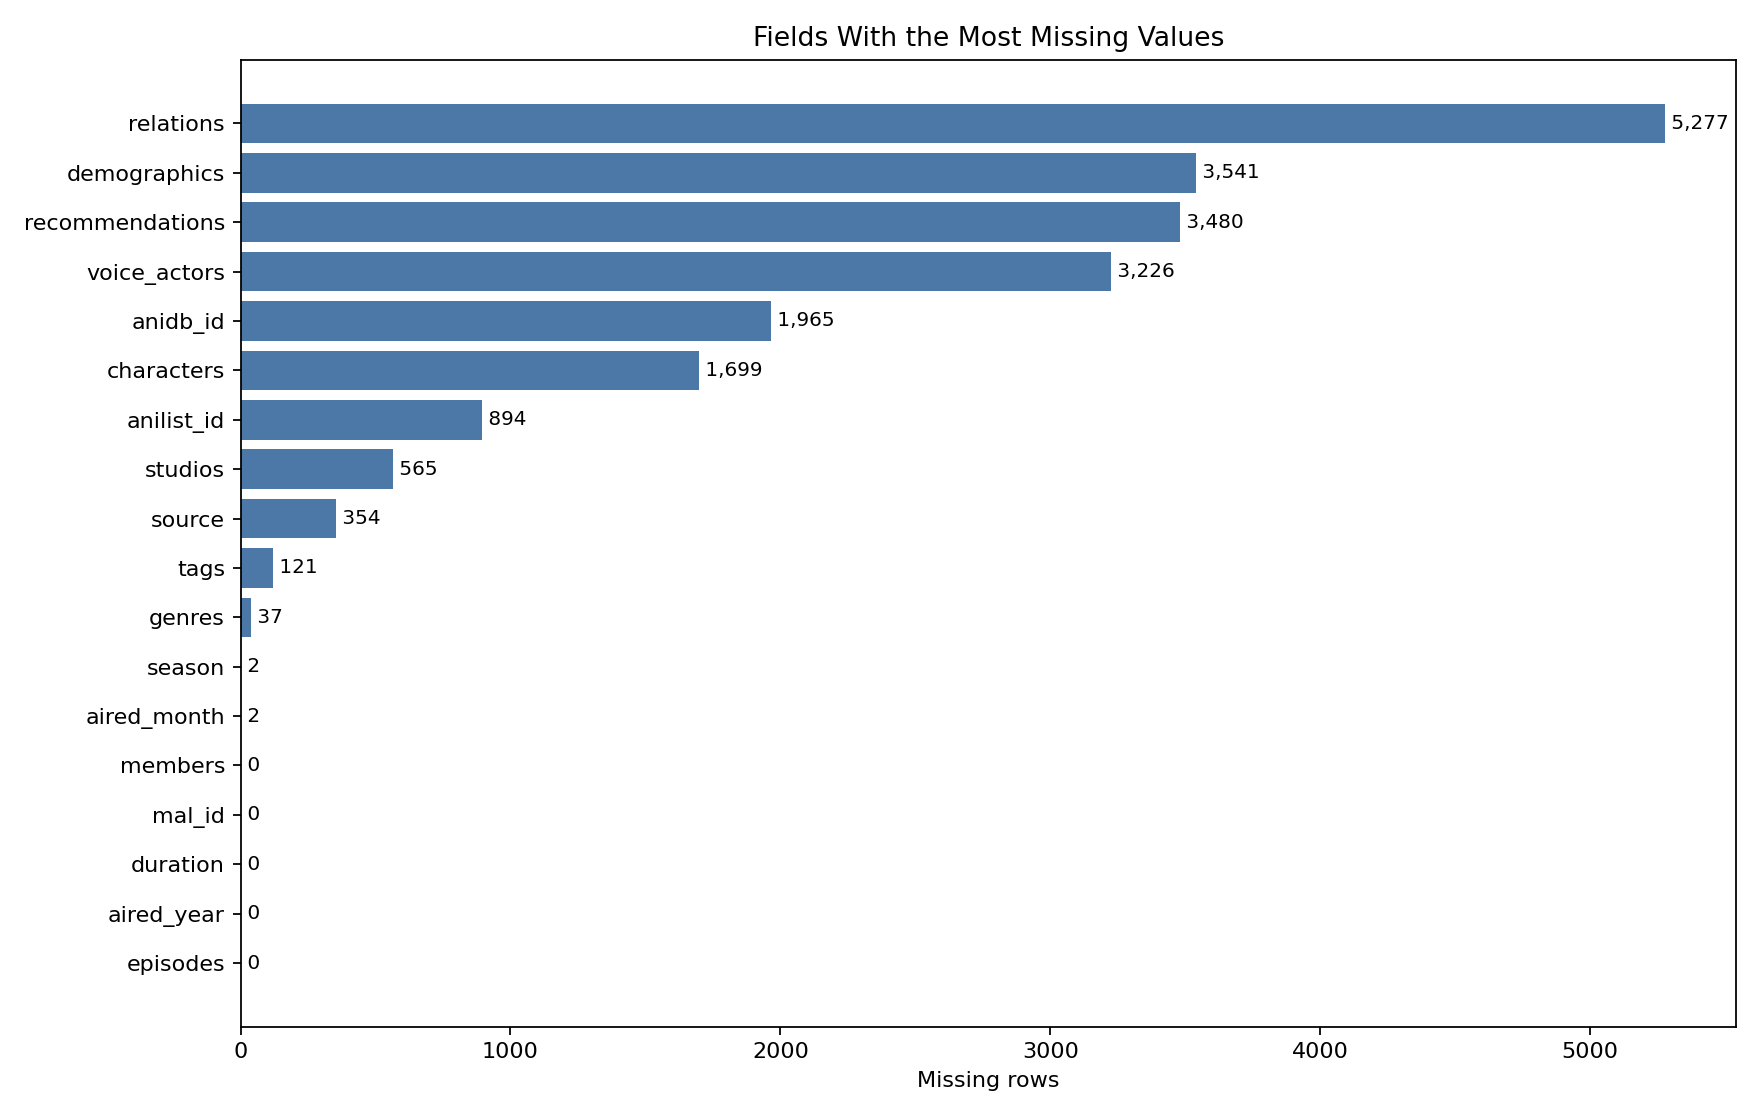

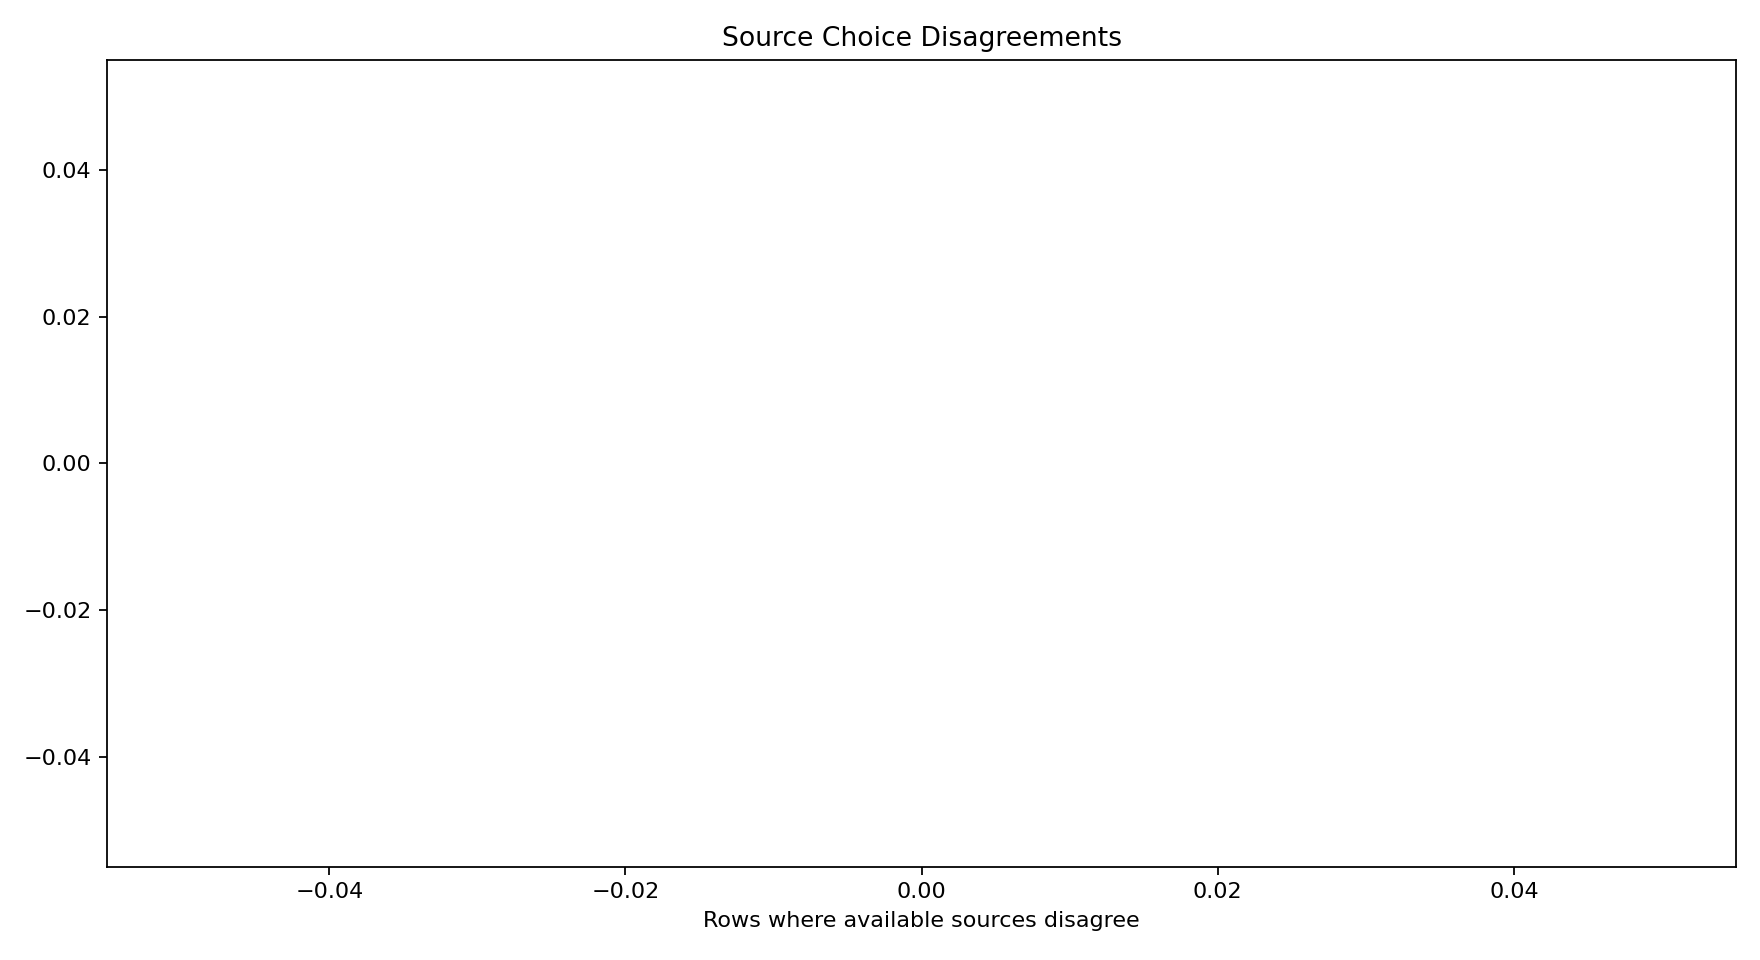

In [7]:
if MISSINGNESS_PLOT.exists():
    display(Image(filename=str(MISSINGNESS_PLOT)))

if CHOICE_PLOT.exists():
    display(Image(filename=str(CHOICE_PLOT)))


## Summary JSON

The summary is useful for reports and for quickly checking whether a rerun changed the dataset shape.


In [8]:
if SUMMARY.exists():
    display(json.loads(SUMMARY.read_text(encoding="utf-8")))


{'updated_at': '2026-07-11T03:23:03',
 'rows': 15492,
 'columns': 35,
 'empty_audit_csv': 'C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_empty_field_audit.csv',
 'choice_audit_csv': 'C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_source_choice_audit.csv',
 'discrepancy_examples_csv': 'C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_source_discrepancy_examples.csv',
 'recap_audit_csv': 'C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\data\\build\\audits\\dataset_recap_flag_audit.csv',
 'missingness_plot': 'C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\artifacts\\plots\\eda\\dataset_missingness_audit.png',
 'choice_plot': 'C:\\Users\\CHAMPUX\\Downloads\\UPC TRABAJOS 2026\\BIG DATA\\proyect\\artifacts\\plots\\eda\\dataset_choice_disagreements.png',
 'largest_missing_fields': [{'field': 'relation